# Hindustani Vocal Transcription — Multi-Raga Demo

This notebook demonstrates the full transcription pipeline from Jain & Arthur (2023) DLfM,
extended with **adaptive windowing**, evaluated across **all 11 OHV-annotated ragas**
using the Saraga 1.5 Hindustani dataset.

In [5]:
# Cell 0 — Setup, Imports & OHV→Saraga Mapping
import sys, json
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("..") if Path("../configs").exists() else Path(".")
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from hcm_transcription.preprocessing import TonicNormalizer
from hcm_transcription.segmentation import (
    StaticWindower, AdaptiveWindower, segment_phrases,
)
from hcm_transcription.ornamentation import OrnamentClassifier, LabelMapper
from hcm_transcription.evaluation import (
    weighted_normalized_levenshtein, evaluate_file,
    boundary_hit_rate, ornament_classification_report,
)
from hcm_transcription.utils import load_config, load_raga_dict
from data.loaders.saraga_loader import SaragaHindustaniLoader
from data.loaders.ohv_loader import OHVLoader
from hcm_transcription.mapping import MAPPING

cfg = load_config(str(ROOT / "configs" / "default.yaml"))
raga_dict = load_raga_dict(str(ROOT / "data" / "raga_dict.json"))

OHV_PATH = (ROOT / cfg["data"]["ohv_data_path"]).resolve()

print(f"Config loaded. Ragas in dict: {len(raga_dict['ragas'])}")

Config loaded. Ragas in dict: 37


In [6]:
loader = SaragaHindustaniLoader(ROOT)

loaded_tracks = {}

for raga_name, entry in MAPPING.items():
    track_id = entry["track_id"]
    if track_id in loaded_tracks:
        continue

    track = loader.load_track(track_id)
    track.raga = raga_name
    
    n_phrases = len(track.phrases) if track.phrases else 0
    duration = track.f0_times[-1] if len(track.f0_times) else 0

    loaded_tracks[track_id] = track

    print(
        f"  Loaded {track_id:30s} | {track.raga:20s} | tonic={track.tonic:.2f} Hz | "
        f"{duration:.0f}s | {len(track.f0_freqs):,} samples | phrases={n_phrases}"
    )

print(f"\n{len(loaded_tracks)} unique Saraga tracks loaded.")

  Loaded 66_Aahir_Bhairon               | Aahir Bhairon        | tonic=138.59 Hz | 589s | 132,505 samples | phrases=24
  Loaded 51_Raag_Bairagi                | Bairagi              | tonic=146.83 Hz | 2513s | 565,510 samples | phrases=77
  Loaded 80_Bhairavi_Dadra              | Bhairavi Dadra       | tonic=155.56 Hz | 602s | 135,350 samples | phrases=7
  Loaded 50_Irani_Bhairavi_Thumri       | Irani Bhairavi Thumri | tonic=196.00 Hz | 360s | 81,071 samples | phrases=4
  Loaded 73_Kalavati                    | Kalavati             | tonic=138.59 Hz | 344s | 77,309 samples | phrases=18
  Loaded 56_Raag_Malkauns               | Malkauns             | tonic=141.01 Hz | 2287s | 514,516 samples | phrases=50
  Loaded 54_Raag_Chandrakauns           | Chandrakauns         | tonic=141.01 Hz | 236s | 53,041 samples | phrases=3
  Loaded 55_Majh_Khamaj_Thumri          | Majh Khamaj Thumri   | tonic=141.01 Hz | 319s | 71,790 samples | phrases=23
  Loaded 65_Nat_Bhairon                 | Nat Bhairo

  Preprocessed 66_Aahir_Bhairon               | ahir_bhairon         | 132,505 frames | 589s
  Preprocessed 51_Raag_Bairagi                | bairagi              | 565,510 frames | 2513s
  Preprocessed 80_Bhairavi_Dadra              | bhairavi_dadra       | 135,350 frames | 602s
  Preprocessed 50_Irani_Bhairavi_Thumri       | irani_bhairavi       | 81,071 frames | 360s
  Preprocessed 73_Kalavati                    | kalavati             | 77,309 frames | 344s
  Preprocessed 56_Raag_Malkauns               | malkauns             | 514,516 frames | 2287s
  Preprocessed 54_Raag_Chandrakauns           | chandrakauns         | 53,041 frames | 236s
  Preprocessed 55_Majh_Khamaj_Thumri          | majh_khamaj_thumri   | 71,790 frames | 319s
  Preprocessed 65_Nat_Bhairon                 | nat_bhairav          | 143,502 frames | 638s
  Preprocessed 68_Raageshree                  | raageshree           | 110,670 frames | 492s
  Preprocessed 53_Raag_Todi                   | todi                 | 9

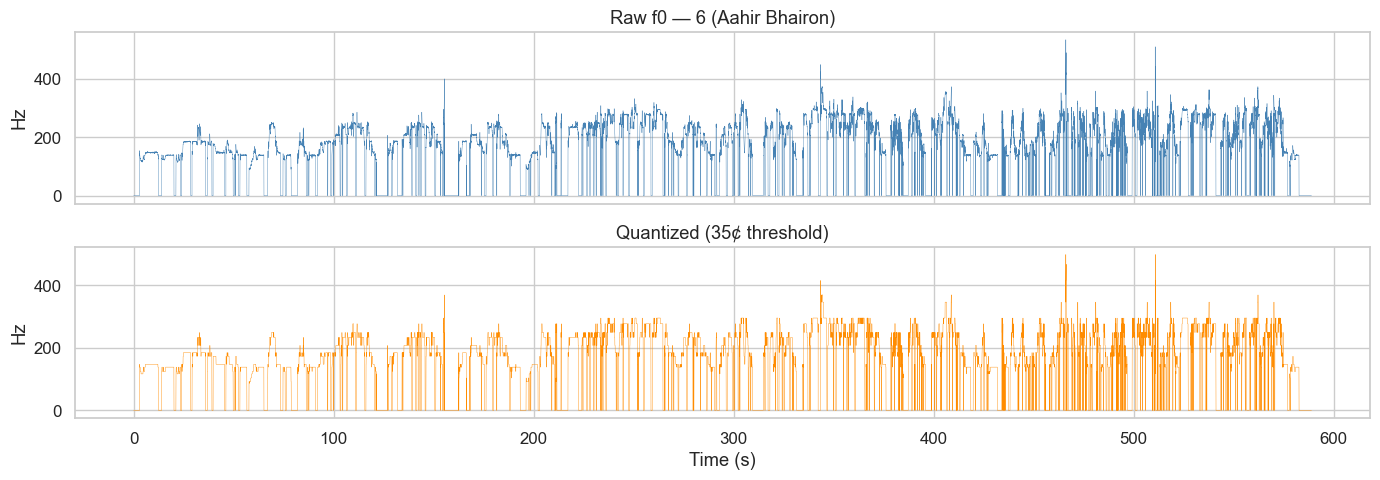


Preprocessed 11 tracks.


In [7]:
# Preprocessing: Tonic Normalization & Quantization (all tracks)

# TODO: change the raga dict or mapping so this does not have to repeat
RAGA_NAME_TO_KEY = {
    "Aahir Bhairon": "ahir_bhairon",
    "Bairagi": "bairagi",
    "Bhairavi Dadra": "bhairavi_dadra",
    "Irani Bhairavi Thumri": "irani_bhairavi",
    "Kalavati": "kalavati",
    "Malkauns": "malkauns",
    "Chandrakauns": "chandrakauns",
    "Majh Khamaj Thumri": "majh_khamaj_thumri",
    "Nat Bhairon": "nat_bhairav",
    "Raageshree": "raageshree",
    "Todi": "todi",
}

preprocessed = {}  # track_id → dict with labels, quant_hz, normalizer

for track_id, trk in loaded_tracks.items():
    raga_key = RAGA_NAME_TO_KEY[trk.raga]
    norm = TonicNormalizer(
        tonic_hz=trk.tonic,
        raga_name=raga_key,
        raga_dict=raga_dict,
        shruti_threshold_cents=cfg["preprocessing"]["shruti_threshold_cents"],
    )
    labels, quant_hz = norm.quantize(trk.f0_freqs)
    preprocessed[track_id] = {
        "labels": labels,
        "quant_hz": quant_hz,
        "norm": norm,
    }

    duration = trk.f0_times[-1] if len(trk.f0_times) else 0
    print(
        f"  Preprocessed {track_id:30s} | {raga_key:20s} | "
        f"{len(labels):,} frames | {duration:.0f}s"
    )

# Show a sample – pick first track for visualization
sample_key = list(loaded_tracks.keys())[0]
sample_trk = loaded_tracks[sample_key]
sample_pp = preprocessed[sample_key]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(sample_trk.f0_times, sample_trk.f0_freqs, lw=0.3, color="steelblue")
axes[0].set_ylabel("Hz"); axes[0].set_title(f"Raw f0 — {sample_key[1]} ({sample_trk.raga})")
axes[1].plot(sample_trk.f0_times, sample_pp["quant_hz"], lw=0.3, color="darkorange")
axes[1].set_ylabel("Hz"); axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"Quantized ({cfg['preprocessing']['shruti_threshold_cents']}¢ threshold)")
plt.tight_layout(); plt.show()

print(f"\nPreprocessed {len(preprocessed)} tracks.")

In [8]:
# Phrase Segmentation & Ornamentation Detection (all tracks)

classifier = OrnamentClassifier.from_config(cfg)
static_w = StaticWindower.from_config(cfg)
sample_period = cfg["data"]["f0_sample_period_s"]

track_results = {}  # (album, track_name) → dict with phrases, events

for track_id, trk in loaded_tracks.items():
    pp = preprocessed[track_id]
    phrases = segment_phrases(
        f0_hz=trk.f0_freqs, times=trk.f0_times,
        quantized_hz=pp["quant_hz"], swara_labels=pp["labels"],
        min_silence_duration_s=cfg["segmentation"]["min_silence_duration_ms"] / 1000.0,
        sample_period_s=sample_period,
    )
    events = []
    for phrase in phrases:
        instab = static_w.compute_instability(phrase.quantized_hz)
        phrase_times = trk.f0_times[phrase.start_idx:phrase.end_idx]
        evts = classifier.classify(
            instab, phrase.quantized_hz, phrase_times,
            hop_samples=static_w.hop_samples,
        )
        events.extend(evts)

    track_results[track_id] = {"phrases": phrases, "events": events}
    label_counts = {}
    for ev in events:
        label_counts[ev.label] = label_counts.get(ev.label, 0) + 1
    counts_str = ", ".join(f"{l}:{c}" for l, c in sorted(label_counts.items(), key=lambda x: -x[1]))
    print(f"  {track_id:30s} | {len(phrases):3d} phrases | {len(events):4d} ornaments | {counts_str}")

print(f"\nProcessed {len(track_results)} tracks.")

  66_Aahir_Bhairon               |  77 phrases |    7 ornaments | meend:4, kan:3
  51_Raag_Bairagi                | 326 phrases |   48 ornaments | meend:39, kan:9
  80_Bhairavi_Dadra              |  57 phrases |    9 ornaments | meend:8, kan:1
  50_Irani_Bhairavi_Thumri       |  49 phrases |    8 ornaments | meend:7, kan:1
  73_Kalavati                    |  52 phrases |    4 ornaments | meend:3, kan:1
  56_Raag_Malkauns               | 369 phrases |   61 ornaments | meend:44, kan:17
  54_Raag_Chandrakauns           |  32 phrases |    4 ornaments | meend:4
  55_Majh_Khamaj_Thumri          |  49 phrases |    4 ornaments | meend:3, kan:1
  65_Nat_Bhairon                 |  81 phrases |   10 ornaments | meend:10
  68_Raageshree                  |  66 phrases |    2 ornaments | meend:2
  53_Raag_Todi                   | 639 phrases |  140 ornaments | meend:100, kan:40

Processed 11 tracks.


In [9]:
# Cell 4 — Ornament Boundary Evaluation vs OHV Ground Truth

ohv_loader = OHVLoader(data_path=str(OHV_PATH))
tolerance = cfg["evaluation"]["ornament_boundary_tolerance_s"]

boundary_rows = []
all_pred_labels = []
all_gt_labels = []

for raga_name, entry in MAPPING.items():
    track_id = entry["track_id"]
    raga_key = RAGA_NAME_TO_KEY[raga_name]

    for annotator, csv_name in entry["annotators"].items():
        ohv_id = csv_name.replace(".csv", "")
        ohv_track = ohv_loader.load_track(ohv_id)
        gt_boundaries = ohv_track.boundaries
        gt_labels = [
            a.label for a in ohv_track.annotations
            if LabelMapper.is_classifiable(a.label)
        ]

        res = track_results[track_id]
        pred_boundaries = np.array(sorted(
            set(t for ev in res["events"] for t in [ev.start_time, ev.end_time])
        )) if res["events"] else np.array([])
        pred_labels = [ev.label for ev in res["events"]]

        bhr = boundary_hit_rate(pred_boundaries, gt_boundaries, tolerance)
        boundary_rows.append({
            "ohv_track": ohv_id,
            "raga": raga_key,
            "saraga_track": track_id,
            "n_pred": len(res["events"]),
            "n_gt": len(gt_boundaries),
            "precision": bhr["precision"],
            "recall": bhr["recall"],
            "f1": bhr["f1"],
        })
        all_pred_labels.extend(pred_labels)
        all_gt_labels.extend(gt_labels)

bhr_df = pd.DataFrame(boundary_rows)
print("=== Ornament Boundary Hit Rate (per OHV track) ===")
print(bhr_df.to_string(index=False))
print(f"\n--- Aggregate ---")
print(f"Mean Precision: {bhr_df['precision'].mean():.4f}")
print(f"Mean Recall:    {bhr_df['recall'].mean():.4f}")
print(f"Mean F1:        {bhr_df['f1'].mean():.4f}\n")

[2026-03-13 13:51:19,176] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'kan' without matching start at time 68.673
[2026-03-13 13:51:19,176] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'meend' without matching start at time 188.325
[2026-03-13 13:51:19,184] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'meend' without matching start at time 38.333
[2026-03-13 13:51:19,192] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'kan' without matching start at time 79.880
[2026-03-13 13:51:19,192] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'kan' without matching start at time 82.651
[2026-03-13 13:51:19,195] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'gamak' without matching start at time 185.017
[2026-03-13 13:51:19,203] WARNING [data.loaders.ohv_loader._parse_annotations:139] End label 'kan' without matching start at time 170.806
[2026-03-13 13:51:19,203] WARNIN

=== Ornament Boundary Hit Rate (per OHV track) ===
                  ohv_track               raga             saraga_track  n_pred  n_gt  precision   recall       f1
            AahirBhairon_av       ahir_bhairon         66_Aahir_Bhairon       7   298   0.285714 0.006711 0.013115
                 Bairagi_rj            bairagi          51_Raag_Bairagi      48   178   0.041667 0.022472 0.029197
            BhairaviDadr_av     bhairavi_dadra        80_Bhairavi_Dadra       9   192   0.111111 0.010417 0.019048
   Irani Bhairavi Thumri_sb     irani_bhairavi 50_Irani_Bhairavi_Thumri       8   206   0.500000 0.024272 0.046296
     IraniBhairaviThumri_av     irani_bhairavi 50_Irani_Bhairavi_Thumri       8   202   0.500000 0.034653 0.064815
                Kalavati_vi           kalavati              73_Kalavati       4   272   0.000000 0.000000 0.000000
                Malkauns_sb           malkauns         56_Raag_Malkauns      61   194   0.073770 0.041237 0.052902
                malkauns_vh  

In [10]:
# Cell 5 — Ornament Classification Report

if all_pred_labels and all_gt_labels:
    report = ornament_classification_report(all_pred_labels, all_gt_labels)
    print("=== Ornament Classification Report (all OHV tracks) ===")
    for label, metrics in report.items():
        print(f"  {label:10s}: P={metrics['precision']:.3f}  R={metrics['recall']:.3f}  F1={metrics['f1']:.3f}")
else:
    print("No predicted or ground-truth labels to compare.")

# Comparison with paper baselines
paper_orn = {
    "Boundary Precision": 0.36, "Boundary Recall": 0.62, "Boundary F1": 0.44,
    "kan F1": 0.11, "meend F1": 0.37, "andolan F1": 0.05, "murki F1": 0.46,
}
ours_orn = {
    "Boundary Precision": bhr_df["precision"].mean(),
    "Boundary Recall": bhr_df["recall"].mean(),
    "Boundary F1": bhr_df["f1"].mean(),
}
if all_pred_labels and all_gt_labels:
    for lbl in ["kan", "meend", "andolan", "murki"]:
        ours_orn[f"{lbl} F1"] = report.get(lbl, {}).get("f1", 0.0)

comp_rows = []
for metric in paper_orn:
    comp_rows.append({
        "Metric": metric,
        "Paper": paper_orn[metric],
        "Ours": ours_orn.get(metric, 0.0),
        "Delta": ours_orn.get(metric, 0.0) - paper_orn[metric],
    })
comp_orn_df = pd.DataFrame(comp_rows)
print("\n=== Ornamentation: Ours vs Paper ===")
print(comp_orn_df.to_string(index=False))

=== Ornament Classification Report (all OHV tracks) ===
  andolan   : P=0.000  R=0.000  F1=0.000
  kan       : P=0.165  R=0.263  F1=0.203
  meend     : P=0.441  R=0.737  F1=0.552
  murki     : P=0.000  R=0.000  F1=0.000

=== Ornamentation: Ours vs Paper ===
            Metric  Paper     Ours     Delta
Boundary Precision   0.36 0.240178 -0.119822
   Boundary Recall   0.62 0.020554 -0.599446
       Boundary F1   0.44 0.033634 -0.406366
            kan F1   0.11 0.202703  0.092703
          meend F1   0.37 0.551570  0.181570
        andolan F1   0.05 0.000000 -0.050000
          murki F1   0.46 0.000000 -0.460000


In [11]:
# Cell 6 — Swara Transcription Evaluation (WN-LD) across all tracks

swara_rows = []
frame_size = int(round(cfg["adaptive_windowing"]["base_frame_ms"] / 1000.0 / sample_period))
hop_size = int(round(cfg["adaptive_windowing"]["base_hop_ms"] / 1000.0 / sample_period))

for track_id, trk in loaded_tracks.items():
    if not trk.phrases:
        continue
    pp = preprocessed[track_id]
    aligned_pred, aligned_gt = [], []
    for gt_p in trk.phrases:
        gt_swaras = gt_p.get("swaras", "")
        if not gt_swaras:
            continue
        s_idx = max(0, int(gt_p["start"] / sample_period))
        e_idx = min(int(gt_p["end"] / sample_period), len(pp["labels"]))
        stable = pp["norm"].stability_filter(pp["labels"][s_idx:e_idx], frame_size, hop_size)
        pred = pp["norm"].to_reduced_sequence(stable)
        if pred:
            aligned_pred.append(pred)
            aligned_gt.append(gt_swaras)

    if aligned_pred:
        scores = evaluate_file(aligned_pred, aligned_gt)
        swara_rows.append({
            "track": track_id,
            "raga": trk.raga,
            "n_phrases": len(aligned_pred),
            "phrase_wnld": scores["phrase_mean"],
            "phrase_std": scores["phrase_std"],
            "file_wnld": scores["file_score"],
        })

swara_df = pd.DataFrame(swara_rows)
print("=== Swara Transcription WN-LD (per track) ===")
print(swara_df.to_string(index=False))
print(f"\n--- Aggregate ---")
print(f"Mean Phrase WN-LD: {swara_df['phrase_wnld'].mean():.4f} ± {swara_df['phrase_wnld'].std():.4f}")
print(f"Mean File WN-LD:   {swara_df['file_wnld'].mean():.4f}")

# Paper comparison
paper_swara = {"Phrase WN-LD": 0.62, "File WN-LD": 0.56}
ours_swara = {"Phrase WN-LD": swara_df["phrase_wnld"].mean(), "File WN-LD": swara_df["file_wnld"].mean()}
comp_swara = pd.DataFrame([
    {"Metric": k, "Paper (53 tracks)": paper_swara[k],
     "Ours (11 OHV tracks)": ours_swara[k],
     "Delta": ours_swara[k] - paper_swara[k]}
    for k in paper_swara
])
print("\n=== Swara: Ours vs Paper ===")
print(comp_swara.to_string(index=False))

=== Swara Transcription WN-LD (per track) ===
                   track                  raga  n_phrases  phrase_wnld  phrase_std  file_wnld
        66_Aahir_Bhairon         Aahir Bhairon         24     0.572917    0.283938   0.612069
         51_Raag_Bairagi               Bairagi         77     0.675866    0.215893   0.690141
       80_Bhairavi_Dadra        Bhairavi Dadra          7     0.608333    0.096465   0.608108
50_Irani_Bhairavi_Thumri Irani Bhairavi Thumri          4     0.333333    0.204124   0.454545
             73_Kalavati              Kalavati         18     0.731481    0.101324   0.734043
        56_Raag_Malkauns              Malkauns         50     0.701667    0.215278   0.718750
    54_Raag_Chandrakauns          Chandrakauns          3     0.833333    0.136083   0.833333
   55_Majh_Khamaj_Thumri    Majh Khamaj Thumri         23     0.684783    0.250551   0.679245
          65_Nat_Bhairon           Nat Bhairon         34     0.713235    0.185725   0.724490
           68_

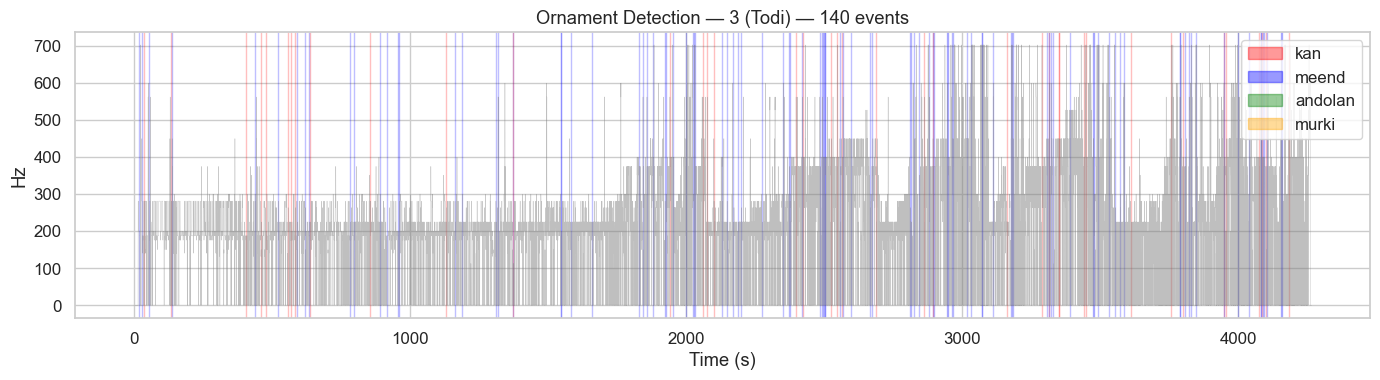

In [12]:
# Cell 7 — Visualization: Ornament Detection on Sample Track

# Pick a track with many ornaments for visualization
viz_key = max(track_results, key=lambda k: len(track_results[k]["events"]))
viz_trk = loaded_tracks[viz_key]
viz_pp = preprocessed[viz_key]
viz_res = track_results[viz_key]

color_map = {"kan": "red", "meend": "blue", "andolan": "green", "murki": "orange"}
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(viz_trk.f0_times, viz_pp["quant_hz"], lw=0.3, color="grey", alpha=0.5)
for ev in viz_res["events"]:
    c = color_map.get(ev.label, "black")
    ax.axvspan(ev.start_time, ev.end_time, alpha=0.25, color=c)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Hz")
ax.set_title(f"Ornament Detection — {viz_key[1]} ({viz_trk.raga}) — {len(viz_res['events'])} events")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, alpha=0.4, label=l) for l, c in color_map.items()], loc="upper right")
plt.tight_layout(); plt.show()

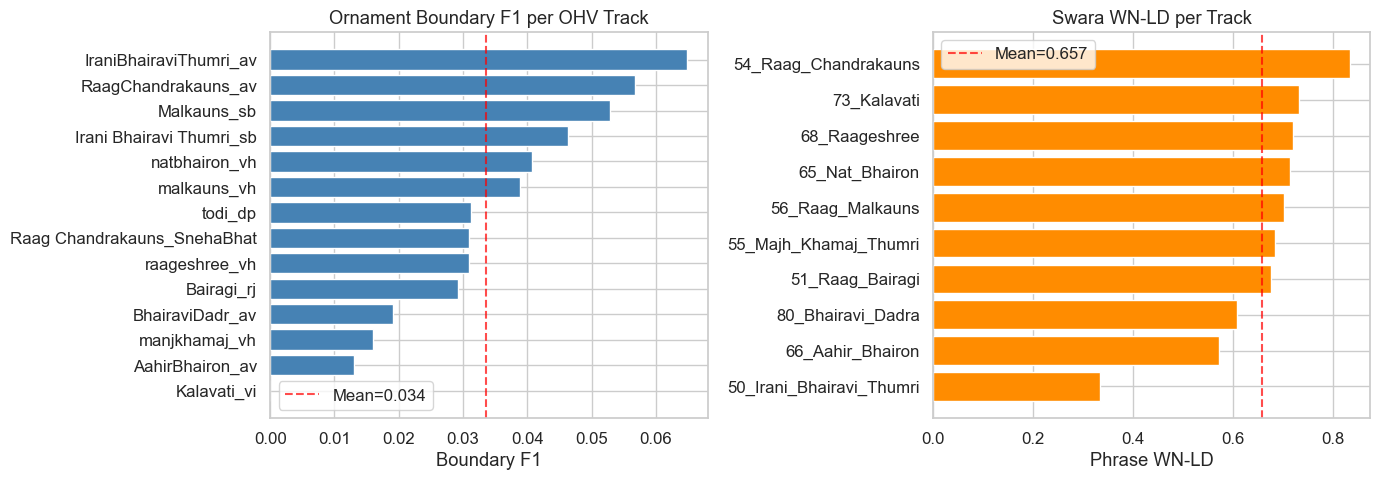

In [13]:
# Cell 8 — Per-Raga Boundary F1 Bar Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boundary F1 per OHV track
bhr_sorted = bhr_df.sort_values("f1", ascending=True)
axes[0].barh(bhr_sorted["ohv_track"], bhr_sorted["f1"], color="steelblue")
axes[0].set_xlabel("Boundary F1"); axes[0].set_title("Ornament Boundary F1 per OHV Track")
axes[0].axvline(bhr_df["f1"].mean(), color="red", linestyle="--", alpha=0.7, label=f"Mean={bhr_df['f1'].mean():.3f}")
axes[0].legend()

# Swara WN-LD per track
if len(swara_df) > 0:
    sw_sorted = swara_df.sort_values("phrase_wnld", ascending=True)
    axes[1].barh(sw_sorted["track"], sw_sorted["phrase_wnld"], color="darkorange")
    axes[1].set_xlabel("Phrase WN-LD"); axes[1].set_title("Swara WN-LD per Track")
    axes[1].axvline(swara_df["phrase_wnld"].mean(), color="red", linestyle="--", alpha=0.7,
                    label=f"Mean={swara_df['phrase_wnld'].mean():.3f}")
    axes[1].legend()

plt.tight_layout(); plt.show()

In [14]:
# Cell 9 — Summary

print("=" * 70)
print("MULTI-RAGA EVALUATION SUMMARY")
print("=" * 70)
print(f"OHV annotation files evaluated:  {len(MAPPING)}")
print(f"Unique Saraga tracks processed:  {len(loaded_tracks)}")
print()
total_events = sum(len(r["events"]) for r in track_results.values())
total_phrases = sum(len(r["phrases"]) for r in track_results.values())
print(f"Total phrases detected:   {total_phrases}")
print(f"Total ornament events:    {total_events}")
print()
print("--- Ornament Boundary Evaluation ---")
print(f"  Mean Precision: {bhr_df['precision'].mean():.4f}")
print(f"  Mean Recall:    {bhr_df['recall'].mean():.4f}")
print(f"  Mean F1:        {bhr_df['f1'].mean():.4f}")
print()
if len(swara_df) > 0:
    print("--- Swara Transcription ---")
    print(f"  Mean Phrase WN-LD: {swara_df['phrase_wnld'].mean():.4f} ± {swara_df['phrase_wnld'].std():.4f}")
    print(f"  Mean File WN-LD:   {swara_df['file_wnld'].mean():.4f}")
    print()
    print("--- Best / Worst tracks (Phrase WN-LD) ---")
    best = swara_df.loc[swara_df["phrase_wnld"].idxmax()]
    worst = swara_df.loc[swara_df["phrase_wnld"].idxmin()]
    print(f"  Best:  {best['track']} ({best['raga']}) = {best['phrase_wnld']:.4f}")
    print(f"  Worst: {worst['track']} ({worst['raga']}) = {worst['phrase_wnld']:.4f}")
print("=" * 70)

MULTI-RAGA EVALUATION SUMMARY
OHV annotation files evaluated:  11
Unique Saraga tracks processed:  11

Total phrases detected:   1797
Total ornament events:    297

--- Ornament Boundary Evaluation ---
  Mean Precision: 0.2402
  Mean Recall:    0.0206
  Mean F1:        0.0336

--- Swara Transcription ---
  Mean Phrase WN-LD: 0.6575 ± 0.1338
  Mean File WN-LD:   0.6785

--- Best / Worst tracks (Phrase WN-LD) ---
  Best:  54_Raag_Chandrakauns (Chandrakauns) = 0.8333
  Worst: 50_Irani_Bhairavi_Thumri (Irani Bhairavi Thumri) = 0.3333
